In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"  # or a lower number like 2, 4, or 8

import sys, re, torch, time, PINN, palantir
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm.auto import tqdm
# PINN
from PINN import reader, models, pl, tl
import de_test
# plot
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages

from de_select_fun import *

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [2]:
from importlib import reload

In [3]:
mmTF = pd.read_csv("data/mouse_geneset/allTFs_mm.txt", sep='\t',  names=['gene_symbol'])

adata = sc.read_h5ad("data/tom_pos.h5ad")
adata_raw = adata.raw.to_adata()

ad_palantir = sc.read_h5ad("data/tom_pos_palantir_Jun4.h5ad")
ad_palantir

impute_x_reload = np.load("data/tom_pos_raw_impute_X.npy", allow_pickle=True).item()
adata_raw.layers['MAGIC_imputed_data'] = impute_x_reload

#  Compute TF trends along palantir pseudotime
for key in ['g', 'v_sum', 'v_norm', 'nabla_v', 'D', 'DM_EigenVectors_multiscaled', 'palantir_fate_probabilities', 'branch_masks']:
    adata_raw.obsm[key] = ad_palantir.obsm[key].copy()

for key in [ 'DM_Kernel', 'DM_Similarity', 'DM_connectivities', 'DM_distances']:
    adata_raw.obsp[key] = ad_palantir.obsp[key].copy()

adata_raw.obs['palantir_pseudotime'] = ad_palantir.obs['palantir_pseudotime'].copy()

impute_x_reload = np.load("data/tom_pos_raw_impute_X.npy", allow_pickle=True).item()
adata_raw.layers['MAGIC_imputed_data'] = impute_x_reload
tf_trends = palantir.presults.compute_gene_trends(
    adata_raw,
    expression_key='MAGIC_imputed_data',  # Use the layer with TF activity
    pseudo_time_key='palantir_pseudotime',
)

Bas/MC prog


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[2025-06-19 22:38:51,066] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (10,626) and rank = 1.0.
[2025-06-19 22:38:51,067] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-19 22:38:52,576] [INFO    ] Sigma interpreted as element-wise standard deviation.
Mono/DC prog
[2025-06-19 22:38:56,527] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (14,157) and rank = 1.0.
[2025-06-19 22:38:56,528] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-19 22:38:57,545] [INFO    ] Sigma interpreted as element-wise standard deviation.
Neu
[2025-06-19 22:39:02,439] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (19,049) and rank = 1.0.
[2025-06-19 22:39:02,440] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-19 22:39:03,520] [INFO    ] Sigma interpreted as element-wise standard deviation.
Ly
[2025-06-19 22:39:08,127] [INFO    ] Using sparse Gaussian Process since n_landm

In [4]:
ad_palantir

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [5]:
mask = pd.read_csv("data/tom_pos_palantir_branch_mask.csv", index_col=0)

In [6]:
adata_lin = {}
v_project = {}
g_project = {}
x_project = {}
pdt_bin_lineage = {}

for lineage in ['Neu', 'Meg', 'Ery']:
    # ad = adata_raw[adata_raw.obsm['branch_masks'][lineage]].copy()
    ad = adata_raw[mask[lineage]].copy()
    pdt_max = ad.obs['palantir_pseudotime'].max()

    # Normalize the pseudotime
    x = np.linspace(0, pdt_max, 100)
    x_project[lineage] = (x[1:] + x[:-1])/2
    v_project[lineage] = tl.aggregate_params_by_pseudotime(ad, ad.obsm['v_norm'].T, 
                                            param_names='v', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=100, return_y=True)

    g_project[lineage] = tl.aggregate_params_by_pseudotime(ad, ad.obsm['g'].T, 
                                            param_names='g', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=100, return_y=True)

    pdt_bins = np.linspace(0, pdt_max, 21)
    pdt_bin_lineage[lineage] = pdt_bins
    pdt_label = np.round((pdt_bins[1:] + pdt_bins[:-1])/2, 2)
    ad.obs['pseudotime_bin'] = pd.cut(ad.obs['palantir_pseudotime']
                                            ,bins=20,labels = pdt_label).astype(float)
    
    adata_lin[lineage] = ad
    print(adata_lin[lineage].obs['pseudotime_bin'].unique())

[0.39 0.67 0.35 0.3  0.44 0.25 0.53 0.48 0.58 0.62 0.21 0.81 0.76 0.9
 0.07 0.16 0.71 0.85 0.12 0.02]
[0.34 0.37 0.26 0.28 0.42 0.39 0.31 0.45 0.47 0.23 0.53 0.5  0.07 0.18
 0.15 0.2  0.12 0.09 0.04 0.01]
[0.38 0.32 0.45 0.55 0.25 0.58 0.42 0.28 0.62 0.35 0.52 0.48 0.65 0.22
 0.08 0.18 0.15 0.12 0.05 0.02]


In [7]:
# Ery

In [91]:
Ery_ad = adata_raw[mask['Ery']].copy()

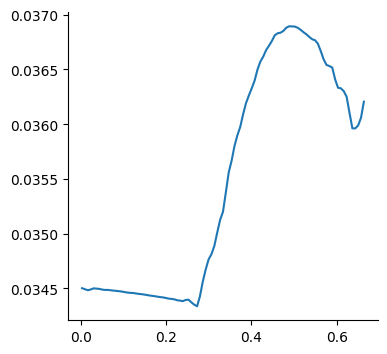

In [136]:
plt.plot(x_project['Ery'],v_project['Ery'][7])

In [133]:
## fit GAM

In [93]:
expression_matrix, cell_time, genes = get_input(adata_lin, 'Ery')
gam_fit_Ery = de_test.run_fitGAM_parallel(expression_matrix, cell_time, genes, n_cores=10)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [152]:
Ery_expr_df = prepare_expression_data(gam_fit_Ery, pseudotime=x_project['Ery'][10:])

In [94]:
## run test and calculate corr and mi

In [286]:
lineage = 'Ery'

steepest_region = find_steepest_region(x_project, v_project, day_id, min_bins=30)
pseudotime_range = (0.2, 0.45)
# # Run association tests

print(f"Running association test for {lineage} lineage...")
test = de_test.AssociationTest(gam_fit_Ery, ['lineage'])
result_lin_day = test.association_test(restrcited_pseudotime=pseudotime_range)
result_lin_day['gene_symbol'] = gam_fit_Ery['gene_symbol']


pseudotime_mask = np.logical_and(x_project['Ery'] >= pseudotime_range[0], x_project['Ery'] <= pseudotime_range[1]) 
bound_istart = np.where(pseudotime_mask)[0][0]
bound_iend = np.where(pseudotime_mask)[0][-1]

log2fc_dict = Ery_expr_df.iloc[[bound_istart-10, bound_iend-10]].apply(np.log2).diff().T.iloc[:,1].to_dict()

result_lin_day['log2fc'] = result_lin_day['gene_symbol'].map(log2fc_dict)

Running association test for Ery lineage...


In [288]:
lineage = 'Ery'

steepest_region = find_steepest_region(x_project, v_project, day_id, min_bins=30)
pseudotime_range = (0.2, 0.45)
# # Run association tests

print(f"Running association test for {lineage} lineage...")
test = de_test.AssociationTest(gam_fit_Ery, ['lineage'])
result_lin_day = test.association_test(restrcited_pseudotime=pseudotime_range)
result_lin_day['gene_symbol'] = gam_fit_Ery['gene_symbol']


pseudotime_mask = np.logical_and(x_project['Ery'] >= pseudotime_range[0], x_project['Ery'] <= pseudotime_range[1]) 
bound_istart = np.where(pseudotime_mask)[0][0]
bound_iend = np.where(pseudotime_mask)[0][-1]

log2fc_dict = Ery_expr_df.iloc[[bound_istart-10, bound_iend-10]].apply(np.log2).diff().T.iloc[:,1].to_dict()

result_lin_day['log2fc'] = result_lin_day['gene_symbol'].map(log2fc_dict)

for day_id in [0,1,7]:

    day = adata_raw.uns['pop']['t'][day_id]
    
    result_lin_day.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_associationtest.csv", index=False)

    # select significantly DE genes and annotate TF
    print(f"Selecting significantly DE genes for {lineage} lineage...")
    # significant_genes = select_top_de_genes(result_lin_day, qval_threshold=5e-2)
    significant_genes = result_lin_day.dropna().query("`pvalue` < 1e-2")
    significant_genes['is_TF'] = significant_genes['gene_symbol'].isin(mmTF['gene_symbol'])
    significant_genes.set_index("gene_symbol", inplace=True)

    # compute parameter derivative
    print(f"Selecting drift derivative related genes for {lineage} lineage...")
    dx = x_project[lineage][0]
    drift_derivatives = np.gradient(v_project[lineage][day_id], dx)

    # compute correlation and mutual information
    pseudotime_mask = np.logical_and(x_project['Ery'] >= pseudotime_range[0], x_project['Ery'] <= pseudotime_range[1]) 
    bound_istart = np.where(pseudotime_mask)[0][0]
    bound_iend = np.where(pseudotime_mask)[0][-1]
    
    
    corr_list = [pearsonr(Ery_expr_df[gene].values, drift_derivatives[10:])[0] for gene in significant_genes.index]
    mi_list = [calculate_mutual_information(Ery_expr_df.loc[:,gene].values, drift_derivatives[10:]) for gene in significant_genes.index]

    significant_genes['pearson_r'] = corr_list
    significant_genes['mutual_information'] = mi_list

    significant_genes.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_sigDE.csv", index=True)

Running association test for Ery lineage...
Selecting significantly DE genes for Ery lineage...
Selecting drift derivative related genes for Ery lineage...
Selecting significantly DE genes for Ery lineage...
Selecting drift derivative related genes for Ery lineage...
Selecting significantly DE genes for Ery lineage...
Selecting drift derivative related genes for Ery lineage...


In [290]:
Ery_sig_gene_df = pd.read_csv(f"results/tompos_Ery_GAM/Day161_sigDE.csv", index_col=0)
print(Ery_sig_gene_df.shape)
Ery_sig_gene_df.head()

(2400, 9)


,gene,waldStat,df,pvalue,meanLogFC,log2fc,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,,
Mrpl15,4,17.869653,1.0,2.365634e-05,0.794806,1.567285,False,0.010116,0.880699
Tcea1,7,6.787880,1.0,9.177882e-03,0.523959,1.089720,False,0.391432,0.613397
Rb1cc1,12,7.843864,1.0,5.099350e-03,0.562392,-1.213515,False,0.536561,0.714570
Pcmtd1,16,10.394327,1.0,1.264030e-03,0.775868,-1.316277,False,0.371400,0.788432
Rrs1,19,24.818525,1.0,6.298920e-07,1.316390,2.256401,False,0.127814,0.710183


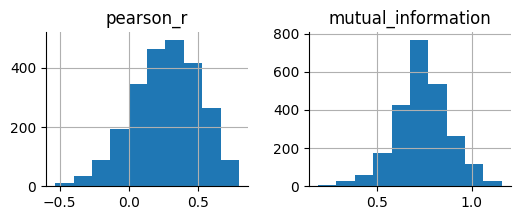

In [291]:
Ery_sig_gene_df[['pearson_r','mutual_information']].hist(figsize=(6,2));

In [301]:
Ery_sig_gene_df.loc[['Gata1', 'Klf1']]

,gene,waldStat,df,pvalue,meanLogFC,log2fc,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,,
Gata1,3031,32.680946,1.0,1.085966e-08,8.584461,11.584402,True,0.201905,0.757594
Klf1,12110,17.999121,1.0,2.210070e-05,9.549415,13.104415,True,-0.146663,0.827949


In [341]:
Ery_sig_TFs = Ery_sig_gene_df.query("  `mutual_information`>0.5 & `is_TF` == True" ).sort_values("meanLogFC", ascending=False)
print(Ery_sig_TFs.shape)
Ery_sig_TFs

(199, 9)


,gene,waldStat,df,pvalue,meanLogFC,log2fc,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,,
Klf1,12110,17.999121,1.0,2.210070e-05,9.549415,13.104415,True,-0.146663,0.827949
Gata1,3031,32.680946,1.0,1.085966e-08,8.584461,11.584402,True,0.201905,0.757594
Mybl2,2732,9.597424,1.0,1.948505e-03,8.530479,11.256714,True,-0.198856,0.799035
E2f8,9432,22.555237,1.0,2.041872e-06,8.460370,11.381448,True,0.547216,0.993791
Brca1,15964,9.599206,1.0,1.946616e-03,6.418783,8.407078,True,0.327859,0.819302
...,...,...,...,...,...,...,...,...,...
Jund,11932,8.910419,1.0,2.835482e-03,0.406060,-1.007020,True,0.645816,0.736453
Tpi1,8402,8.034773,1.0,4.588777e-03,0.383087,0.762237,True,0.215352,0.567023
Rps10,20146,11.306602,1.0,7.723199e-04,0.255576,0.617812,True,0.620046,0.771688


In [175]:
Ery_sig_gene_df.loc[["Gata1", "Klf1", "Tal1","Gypa"]]

,gene,waldStat,df,pvalue,meanLogFC,fdr,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,,
Gata1,3031,7.096655,1.0,7.722796e-03,0.429454,1.855440e-02,True,0.729232,0.496912
Klf1,12110,74.237845,1.0,6.924990e-18,1.837624,2.005038e-15,True,-0.470151,0.304646
Tal1,5340,21.608009,1.0,3.344523e-06,0.707821,3.632464e-05,True,0.595476,0.453566
Gypa,12041,8.726493,1.0,3.136191e-03,9.544564,9.051719e-03,False,-0.730100,0.431450


In [305]:
steepest_region_hand_pick = {'Ery': {'start_bin': 0.25,
  'end_bin': 0.45}}

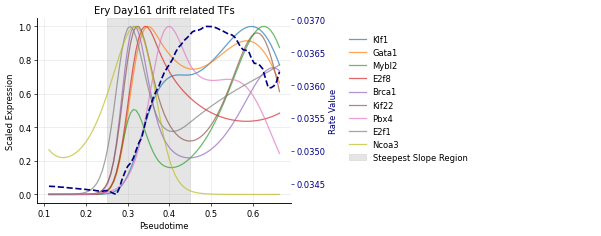

In [318]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_TFs_list = Ery_sig_TFs.index.to_list()[:10]
sig_TFs_list.remove("Timeless")
sig_gene_expr = Ery_expr_df.loc[:,sig_TFs_list].iloc[6:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region_hand_pick, 
    lineage='Ery', 
    day_idx=7,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=(len(sig_TFs_list)//10)+1, frameon=False)
ax1.set_title("Ery Day161 drift related TFs")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Ery_Day161_DETFs.pdf")

In [330]:
Ery_sig_Genes = Ery_sig_gene_df.query("`pearson_r` > 0.2 & `mutual_information`>0.5 " ).sort_values("log2fc", ascending=False)
print(Ery_sig_Genes.shape)
Ery_sig_Genes.head()

(1474, 9)


,gene,waldStat,df,pvalue,meanLogFC,log2fc,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,,
Cst7,2538,10.260264,1.0,1.359262e-03,10.106879,13.864193,False,0.642383,0.602576
Csrp3,9431,7.457889,1.0,6.315905e-03,9.417369,13.697174,False,0.446358,0.546858
Gata1,3031,32.680946,1.0,1.085966e-08,8.584461,11.584402,True,0.201905,0.757594
Hist1h2bj,16499,14.600068,1.0,1.329097e-04,8.566736,11.394420,False,0.352073,0.800764
E2f8,9432,22.555237,1.0,2.041872e-06,8.460370,11.381448,True,0.547216,0.993791


In [332]:
Ery_sig_Genes_neg = Ery_sig_gene_df.query("`pearson_r` < -0.2 & `mutual_information`>0.5 " ).sort_values("log2fc", ascending=False)
print(Ery_sig_Genes_neg.shape)
Ery_sig_Genes_neg.head()

(81, 9)


,gene,waldStat,df,pvalue,meanLogFC,log2fc,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,,
Ermap,5429,10.086211,1.0,0.001494,15.177105,32.501485,False,-0.359157,0.762496
Prss50,14548,6.804988,1.0,0.009090,17.853532,31.845517,False,-0.401231,0.773750
Atp1b2,15333,7.876078,1.0,0.005009,13.887631,22.966715,False,-0.303223,0.523227
Mthfd2,8031,14.411794,1.0,0.000147,8.860566,11.672585,False,-0.245318,0.871427
Aunip,5689,9.476848,1.0,0.002081,8.826414,11.659189,False,-0.293342,0.830279


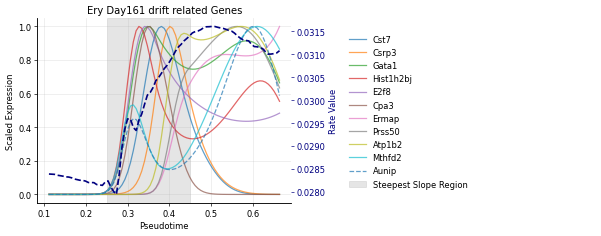

In [339]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_Genes_list = Ery_sig_Genes.index.to_list()[:6]
sig_Genes_list += Ery_sig_Genes_neg.index.to_list()[:5]

sig_gene_expr = Ery_expr_df.loc[:,sig_Genes_list].iloc[6:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region_hand_pick, 
    lineage='Ery', 
    day_idx=1,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=(len(sig_TFs_list)//10)+1, frameon=False)
ax1.set_title("Ery Day161 drift related Genes")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Ery_Day7_DEGenes.pdf")

In [ ]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_Genes_list = Ery_sig_Genes.index.to_list()[:6]
sig_Genes_list += Ery_sig_Genes_neg.index.to_list()[:5]

sig_gene_expr = Ery_expr_df.loc[:,sig_Genes_list].iloc[6:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region_hand_pick, 
    lineage='Ery', 
    day_idx=7,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=(len(sig_TFs_list)//10)+1, frameon=False)
ax1.set_title("Ery Day161 drift related Genes")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Ery_Day161_DEGenes.pdf")

# Meg

In [ ]:
expression_matrix, cell_time, genes = get_input(adata_lin, 'Meg')
gam_fit_Meg = de_test.run_fitGAM_parallel(expression_matrix, cell_time, genes, n_cores=10)


/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [12]:
steepest_region_hand_pick = {'Meg': {'start_bin': 0.25,
  'end_bin': 0.45}}

steepest_region_Day12 = find_steepest_region(x_project, v_project, 2, min_bins=30)
steepest_region_Day12['Meg']

{'start_bin': 0.27657624884321896,
 'end_bin': 0.43540221352546354,
 'mean_slope': 0.03450491,
 'window_idx': (50, 80)}

In [ ]:
pseudotime_range = (0.25,0.45)

test = de_test.AssociationTest(gam_fit_Meg, ['lineage'])
result_lin_day = test.association_test(restrcited_pseudotime=pseudotime_range)
result_lin_day['gene_symbol'] = gam_fit_Meg['gene_symbol']

result_lin_day.to_csv(f"results/tompos_Meg_GAM/Day12_associationtest.csv", index=False)

In [58]:
gene_to_id = dict(zip(gam_fit_Meg['gene_symbol'], gam_fit_Meg['gene_names']))

In [ ]:
significant_genes = result_lin_day.dropna().query("`pvalue` < 1e-2")
significant_genes['is_TF'] = significant_genes['gene_symbol'].isin(mmTF['gene_symbol'])
significant_genes.set_index("gene_symbol", inplace=True)

# head
significant_genes.head()

,gene,waldStat,df,pvalue,meanLogFC,is_TF
gene_symbol,,,,,,
Pcmtd1,16,8.240547,1.0,4.096479e-03,0.763325,False
Rrs1,19,8.423805,1.0,3.703399e-03,0.620013,False
Eya1,44,12.618866,1.0,3.818729e-04,2.134922,False
Mcm3,70,26.417949,1.0,2.749735e-07,0.824260,False
Smap1,87,7.449393,1.0,6.345786e-03,0.469070,False


In [19]:
# GAM Fitted expression
Meg_expr_df = pd.read_csv("results/tompos_Meg_GAM/GAM_scaled_expression.csv", index_col=0).iloc[25:]

scaler = MinMaxScaler()
expreM = Meg_expr_df.values
expreM_scaled = [scaler.fit_transform(expreM[:,[i]]) for i in range(expreM.shape[1])]

# Meg_expr_df = pd.DataFrame(expreM_scaled, columns=Meg_expr_df.columns, index=Meg_expr_df.index)
Meg_expr_df = pd.DataFrame(np.stack(expreM_scaled)[:,:,0].T, columns=Meg_expr_df.columns, index=Meg_expr_df.index)

In [ ]:
# globally  evaluate
lineage = "Meg"
day_id = 2

dx = x_project[lineage][0]
drift_derivatives = np.gradient(v_project[lineage][day_id], dx)

significant_genes['pearson_r'] = [pearsonr(Meg_expr_df[gene].values, drift_derivatives[25:])[0] for gene in significant_genes.index]
significant_genes['mutual_information'] = [calculate_mutual_information(Meg_expr_df.loc[:,gene].values, drift_derivatives[25:]) for gene in significant_genes.index]

# Meg Day 12 saved
significant_genes.to_csv(f"results/tompos_Meg_GAM/Day12_sigDE.csv", index=True)

In [34]:
# Significant DE genes
Meg_sig_gene_df = pd.read_csv(f"results/tompos_Meg_GAM/Day12_sigDE.csv", index_col=0)
print(Meg_sig_gene_df.shape)
Meg_sig_gene_df.head()

(1452, 8)


,gene,waldStat,df,pvalue,meanLogFC,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,
Pcmtd1,16,8.240547,1.0,4.096479e-03,0.763325,False,0.174490,0.239436
Rrs1,19,8.423805,1.0,3.703399e-03,0.620013,False,0.362529,0.973150
Eya1,44,12.618866,1.0,3.818729e-04,2.134922,False,0.140061,0.406421
Mcm3,70,26.417949,1.0,2.749735e-07,0.824260,False,0.458046,0.975411
Smap1,87,7.449393,1.0,6.345786e-03,0.469070,False,0.380803,0.968888


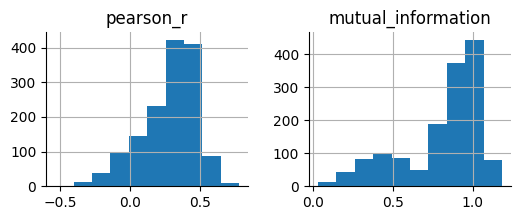

In [35]:
Meg_sig_gene_df[['pearson_r','mutual_information']].hist(figsize=(6,2));

In [36]:
Meg_sig_TFs = Meg_sig_gene_df.query("`mutual_information`>0.6 & `is_TF` == True" ).sort_values("meanLogFC", ascending=False)
print(Meg_sig_TFs.shape)
Meg_sig_TFs

(81, 8)


,gene,waldStat,df,pvalue,meanLogFC,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,
Nkx2-3,21846,11.087958,1.0,8.689010e-04,4.807447,True,-0.255386,0.692719
Mybl2,2732,12.339556,1.0,4.434604e-04,4.124036,True,0.285248,0.917745
E2f8,9432,41.679902,1.0,1.075085e-10,3.927285,True,0.216108,1.059916
Foxm1,8464,10.349291,1.0,1.295244e-03,3.752504,True,0.410102,0.893205
Anxa1,21664,15.527354,1.0,8.131995e-05,3.611562,True,0.112621,0.612913
...,...,...,...,...,...,...,...,...
Ran,7046,16.419446,1.0,5.076178e-05,0.422541,True,0.455555,0.789205
Ybx1,5436,14.769361,1.0,1.214936e-04,0.385821,True,0.418826,0.870849
Cbx3,7739,8.228054,1.0,4.124774e-03,0.385199,True,0.484275,0.811025


In [ ]:
max_express = []
for gene in Meg_sig_gene_df.index:
    max_express.append(gam_fit_Meg['models'][gene_to_id[gene]]['expr'].max())
Meg_sig_gene_df['max_expr'] = max_express

In [71]:
Meg_sig_TFs.to_csv("results/tompos_Meg_GAM/Day12_topTFs.csv")

In [ ]:
# globally  evaluate
lineage = "Meg"
day_id = 2

dx = x_project[lineage][0]
drift_derivatives = np.gradient(v_project[lineage][day_id], dx)

significant_genes['pearson_r'] = [pearsonr(Meg_expr_df[gene].values, drift_derivatives[25:])[0] for gene in significant_genes.index]
significant_genes['mutual_information'] = [calculate_mutual_information(Meg_expr_df.loc[:,gene].values, drift_derivatives[25:]) for gene in significant_genes.index]

In [ ]:
Meg_sig_TFs = Meg_sig_gene_df.query("`mutual_information`>0.6 & `is_TF` == True" ).sort_values("meanLogFC", ascending=False)
print(Meg_sig_TFs.shape)
Meg_sig_TFs

(81, 8)


,gene,waldStat,df,pvalue,meanLogFC,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,
Nkx2-3,21846,11.087958,1.0,8.689010e-04,4.807447,True,-0.255386,0.692719
Mybl2,2732,12.339556,1.0,4.434604e-04,4.124036,True,0.285248,0.917745
E2f8,9432,41.679902,1.0,1.075085e-10,3.927285,True,0.216108,1.059916
Foxm1,8464,10.349291,1.0,1.295244e-03,3.752504,True,0.410102,0.893205
Anxa1,21664,15.527354,1.0,8.131995e-05,3.611562,True,0.112621,0.612913
...,...,...,...,...,...,...,...,...
Ran,7046,16.419446,1.0,5.076178e-05,0.422541,True,0.455555,0.789205
Ybx1,5436,14.769361,1.0,1.214936e-04,0.385821,True,0.418826,0.870849
Cbx3,7739,8.228054,1.0,4.124774e-03,0.385199,True,0.484275,0.811025


In [98]:
from importlib import reload
reload(de_select_fun)

NameError: name 'de_select_fun' is not defined

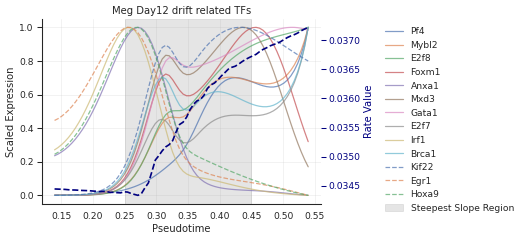

In [119]:
dpi = 60

fig, axs = plt.subplots(1,1, figsize=(6, 4), dpi=dpi, frameon=False)


sig_TFs_list = ['Pf4'] + Meg_sig_TFs.index.to_list()[1:13] 
# sig_TFs_list.remove("Timeless")
sig_gene_expr = Meg_expr_df.loc[:,sig_TFs_list]#.iloc[6:]


steepest_region_hand_pick = {'Meg': {'start_bin': 0.25,
  'end_bin': 0.45}}
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region_hand_pick, 
    lineage='Meg', 
    day_idx=7,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs
    )

# axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.20, 1.0), loc='upper left', ncol=1, frameon=False)
ax1.set_title("Meg Day12 drift related TFs")

sns.despine(ax=ax1)
sns.despine(ax=ax2)
if dpi==600:
    lineage = "Meg"
    day = 12

    fig.savefig(f"figures/tompos_tradeseq/{lineage}_Day{day}_DETFs.pdf", transparent=True, dpi=dpi, bbox_inches='tight')

In [118]:
hoxa9_color = sns.color_palette()[2]
gata1_color = sns.color_palette()[7]

In [ ]:
Meg_expr_df.index.to_list()[Meg_expr_df['Hoxa9'].argmax()]

0.2710994914403829

In [114]:
Meg_expr_df.index.to_list()[Meg_expr_df.iloc[:40]['Gata1'].argmax()]

0.3258670654687431

24

<Axes: >

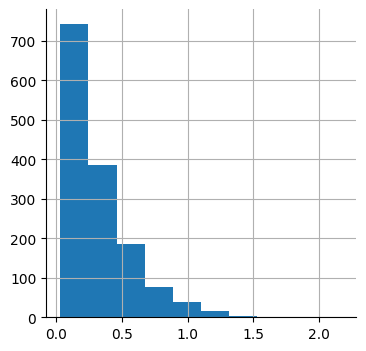

In [75]:
Meg_sig_gene_df['max_expr'].hist()

In [ ]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_genes_list = Meg_sig_genes.index.to_list()[:19]
sig_gene_expr = Meg_expr_df.loc[:,sig_genes_list]#.iloc[10:]

steepest_region_hand_pick = {'Meg': {'start_bin': 0.25,
  'end_bin': 0.45}}
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region_hand_pick, 
    lineage='Meg', 
    day_idx=1,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=(len(sig_genes_list)//10)+1, frameon=False)
ax1.set_title("Meg Day12 drift related genes")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Meg_Day12_DEgenes.pdf")

# testing l2fc

In [216]:
contrast_point = np.linspace(*pseudotime_range, 12)

Gata1_model = gam_fit_Ery['models'][3031]
Gata2_model = gam_fit_Ery['models'][8123]

In [200]:
contrast_point

array([0.3       , 0.31363636, 0.32727273, 0.34090909, 0.35454545,
       0.36818182, 0.38181818, 0.39545455, 0.40909091, 0.42272727,
       0.43636364, 0.45      ])

In [257]:
L_gt1 = Gata1_model['model'].model.smoother.transform(contrast_point[[0,-1]]) @ Gata1_model['model'].params
L_gt2 = Gata2_model['model'].model.smoother.transform(contrast_point[[0,-1]]) @ Gata2_model['model'].params

In [263]:
L_gt1[-1] - L_gt1[0]

0.4294537818622768

In [259]:
L_gt2

array([-1.69751786, -2.60601431])

In [223]:
pred_gt1[-1] / pred_gt1[0]

1.5364183923236836

In [231]:
pred_gt1

array([0.04402127, 0.06488851, 0.08118682, 0.08948238, 0.09017582,
       0.08622846, 0.08115986, 0.07678076, 0.07320812, 0.07046833,
       0.06859428, 0.06763508])

In [229]:
np.log(pred_gt1[-1]/pred_gt1[0])

0.42945398846956373

In [226]:
np.log2(pred_gt2[0]/pred_gt2[-1])

1.3106823574011273

In [256]:
 Gata1_model['pred_func'](x_project['Ery'][[45,66]])

array([0.05436232, 0.06771011])

In [247]:
 Gata1_model['pred_func'](x_project['Ery'])[[30,70]]

array([2.20994974e-05, 6.82879180e-02])

array([0.30661373, 0.44812776])

array([0.3 , 0.45])